# 💎 Diamond Cut Prediction — Clasificación Multiclase Supervisada
## Machine Learning II · Desarrolla un sistema para predecir el corte de diamantes

---

Este notebook implementa y compara cinco modelos de clasificación supervisada para predecir  
el tipo de corte (`cut`) de un diamante a partir de sus características físicas y de precio.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y análisis exploratorio (EDA) |
| 2️⃣ | Preprocesamiento — imputación, codificación, escalado |
| 3️⃣ | División train/test |
| 4️⃣ | Implementación de 5 modelos de clasificación |
| 5️⃣ | Evaluación — accuracy, matriz de confusión, classification_report |
| 6️⃣ | Comparación y conclusiones |

> **Dataset:** `diamonds.csv` — 53 940 registros · 10 columnas  
> **Objetivo:** clasificar `cut` ∈ {Fair, Good, Very Good, Premium, Ideal} (5 clases)  
> **Ruta:** `/workspace/diamonds.csv`


---
## 0. Importación de librerías y configuración


In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

# ── Configuración general ─────────────────────────────────────────────────
INPUT_PATH    = "workspace/diamonds.csv"
SAMPLE_N      = 5000    # filas para la muestra estratificada
USE_FULL_DATA = False   # True → dataset completo (lento para SVC/KNN)
RANDOM_STATE  = 42

# ── Hiperparámetros expuestos para facilitar experimentos / GridSearchCV ──
LR_C          = 1.0    # LogisticRegression: inverso de la regularización L2
KNN_K         = 7      # KNeighborsClassifier: número de vecinos
SVC_C         = 1.0    # SVC: penalización de errores de clasificación
DT_MAX_DEPTH  = 10     # DecisionTree: profundidad máxima del árbol
RF_N_EST      = 200    # RandomForest: número de árboles
RF_MAX_DEPTH  = 12     # RandomForest: profundidad máxima por árbol

print("✅ Librerías y configuración cargadas.")
print(f"   USE_FULL_DATA={USE_FULL_DATA}  |  SAMPLE_N={SAMPLE_N}")
print(f"   Hiperparámetros: LR_C={LR_C}  KNN_K={KNN_K}  SVC_C={SVC_C}  "
      f"DT_MAX_DEPTH={DT_MAX_DEPTH}  RF_N_EST={RF_N_EST}  RF_MAX_DEPTH={RF_MAX_DEPTH}")


✅ Librerías y configuración cargadas.
   USE_FULL_DATA=False  |  SAMPLE_N=5000
   Hiperparámetros: LR_C=1.0  KNN_K=7  SVC_C=1.0  DT_MAX_DEPTH=10  RF_N_EST=200  RF_MAX_DEPTH=12


---
## 1. Carga y Exploración de Datos (EDA)

### 1.1 Carga del dataset


In [2]:
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"\n❌ No se encontró: {INPUT_PATH}\n"
        "   Coloca diamonds.csv en /workspace/ antes de ejecutar."
    )

df_full = pd.read_csv(INPUT_PATH)
print(f"📐 Dimensiones completas: {df_full.shape[0]:,} filas × {df_full.shape[1]} columnas")
print(f"\n📋 Columnas y tipos:")
for col in df_full.columns:
    print(f"  · {col:10s}  dtype={df_full[col].dtype}")


📐 Dimensiones completas: 53,940 filas × 10 columnas

📋 Columnas y tipos:
  · carat       dtype=float64
  · cut         dtype=str
  · color       dtype=str
  · clarity     dtype=str
  · depth       dtype=float64
  · table       dtype=float64
  · price       dtype=int64
  · x           dtype=float64
  · y           dtype=float64
  · z           dtype=float64


### 1.2 Primeras filas

In [3]:
df_full.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### 1.3 Estadísticas descriptivas — variables numéricas

In [4]:
df_full.describe().round(3)

,carat,depth,table,price,x,y,z
count,53940.000,53939.000,53940.000,53940.00,53939.000,53940.000,53930.000
mean,0.798,61.749,57.457,3932.80,5.731,5.735,3.539
std,0.474,1.433,2.234,3989.44,1.122,1.142,0.706
min,0.200,43.000,43.000,326.00,0.000,0.000,0.000
25%,0.400,61.000,56.000,950.00,4.710,4.720,2.910
50%,0.700,61.800,57.000,2401.00,5.700,5.710,3.530
75%,1.040,62.500,59.000,5324.25,6.540,6.540,4.040
max,5.010,79.000,95.000,18823.00,10.740,58.900,31.800


### 1.4 Valores nulos

In [5]:
nulos = df_full.isnull().sum()
nulos_pct = (nulos / len(df_full) * 100).round(4)
nulos_df  = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": nulos_pct})
print("🔍 Valores nulos por columna:")
print(nulos_df.to_string())
print(f"\n  Columnas con nulos: {(nulos > 0).sum()}")


🔍 Valores nulos por columna:
         Nulos  Porcentaje (%)
carat        0          0.0000
cut          0          0.0000
color        0          0.0000
clarity      0          0.0000
depth        1          0.0019
table        0          0.0000
price        0          0.0000
x            1          0.0019
y            0          0.0000
z           10          0.0185

  Columnas con nulos: 3


### 1.5 Distribución de la variable objetivo `cut`

Problema de **clasificación multiclase**: 5 categorías ordenadas de menor a mayor calidad.


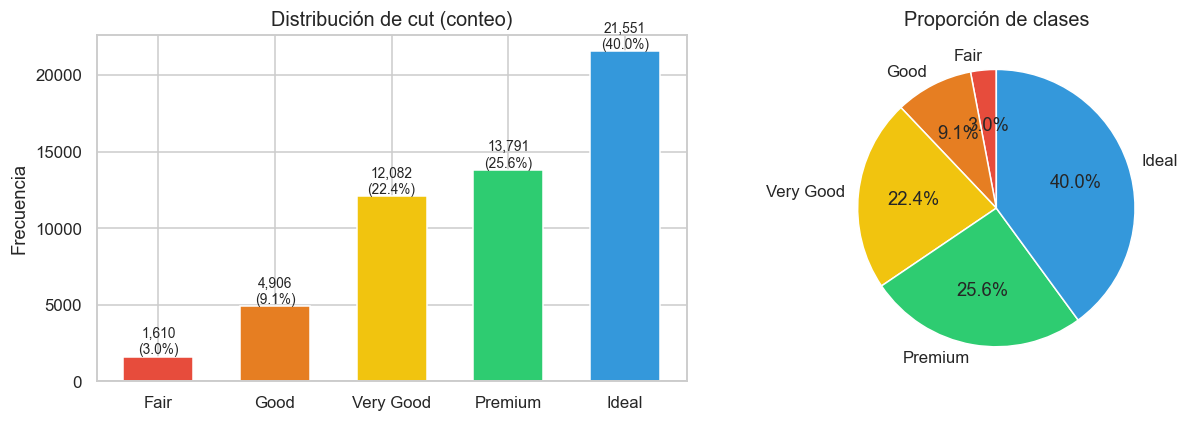


📊 Detalle por clase:
  · Fair        :  1,610  (3.0%)
  · Good        :  4,906  (9.1%)
  · Very Good   : 12,082  (22.4%)
  · Premium     : 13,791  (25.6%)
  · Ideal       : 21,551  (40.0%)

  Clase más frecuente: Ideal (40.0%)
  Clase más escasa:    Fair  (3.0%)
  Desbalance máximo:   13.4x


In [6]:
cut_order  = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
cut_counts = df_full["cut"].value_counts().reindex(cut_order)
cut_pcts   = cut_counts / len(df_full) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ["#e74c3c","#e67e22","#f1c40f","#2ecc71","#3498db"]
axes[0].bar(cut_order, cut_counts.values, color=colores, edgecolor="white", width=0.6)
for i, (v, p) in enumerate(zip(cut_counts.values, cut_pcts.values)):
    axes[0].text(i, v + 200, f"{v:,}\n({p:.1f}%)", ha="center", fontsize=9)
axes[0].set_title("Distribución de cut (conteo)")
axes[0].set_ylabel("Frecuencia")

axes[1].pie(cut_counts.values, labels=cut_order, colors=colores,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Proporción de clases")

plt.tight_layout(); plt.show()

print("\n📊 Detalle por clase:")
for cat, cnt, pct in zip(cut_order, cut_counts.values, cut_pcts.values):
    print(f"  · {cat:12s}: {cnt:6,}  ({pct:.1f}%)")
print(f"\n  Clase más frecuente: Ideal ({cut_pcts['Ideal']:.1f}%)")
print(f"  Clase más escasa:    Fair  ({cut_pcts['Fair']:.1f}%)")
print(f"  Desbalance máximo:   {cut_counts.max()/cut_counts.min():.1f}x")


### 1.6 Distribución de variables numéricas clave

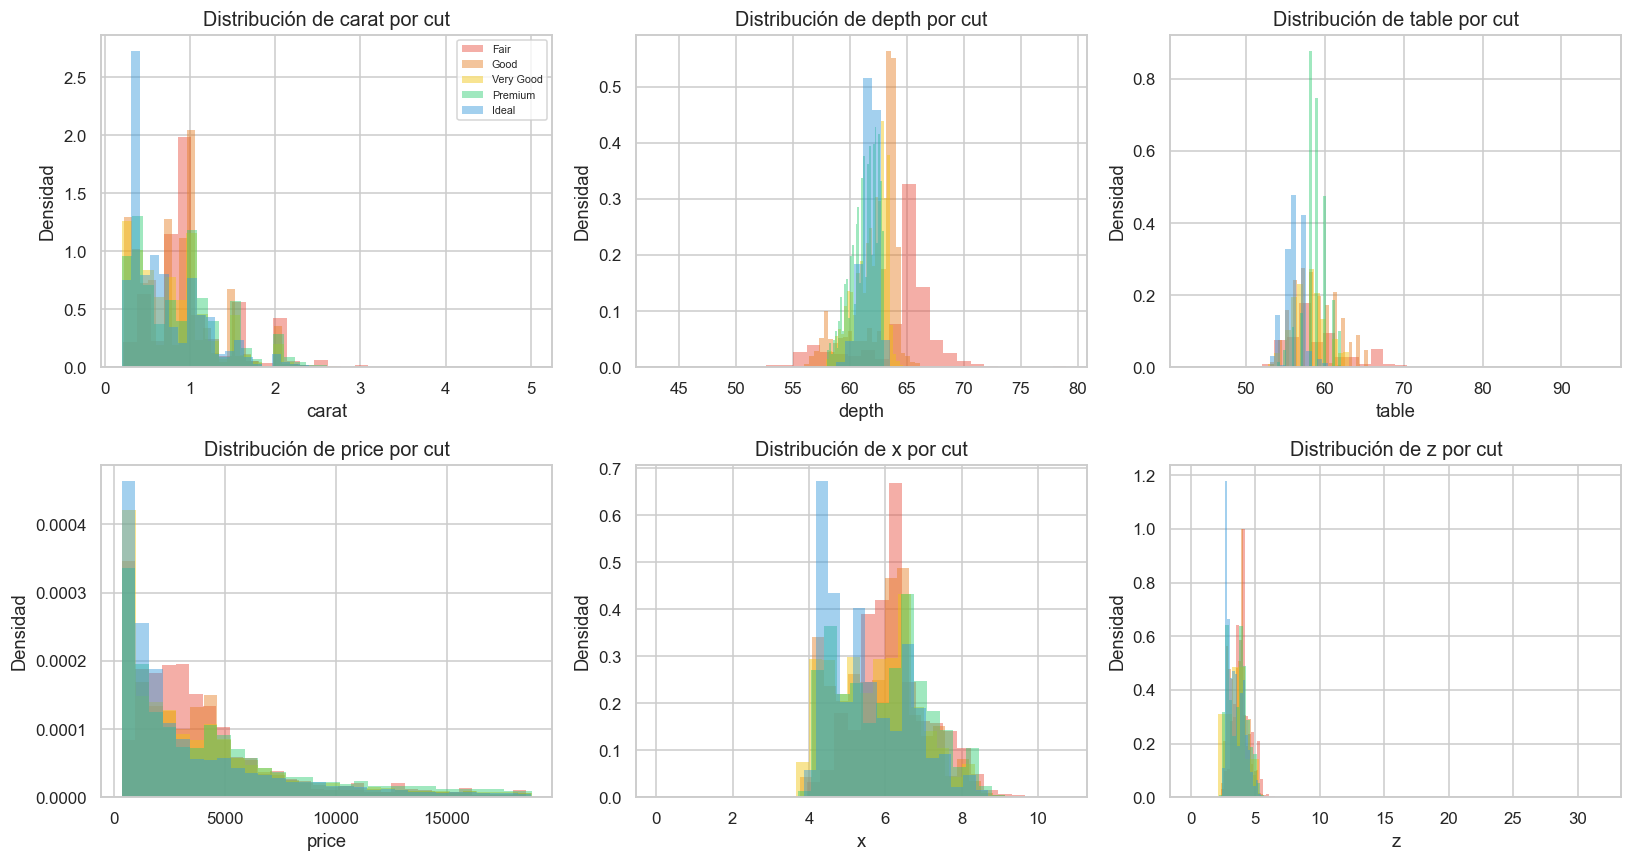

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
num_cols = ["carat","depth","table","price","x","z"]
palette_cut = {"Fair":"#e74c3c","Good":"#e67e22","Very Good":"#f1c40f",
               "Premium":"#2ecc71","Ideal":"#3498db"}

for ax, col in zip(axes, num_cols):
    for cut_val, color in palette_cut.items():
        subset = df_full[df_full["cut"] == cut_val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.45, color=color,
                label=cut_val, edgecolor="none", density=True)
    ax.set_title(f"Distribución de {col} por cut")
    ax.set_xlabel(col); ax.set_ylabel("Densidad")
    if col == "carat":
        ax.legend(fontsize=7)

plt.tight_layout(); plt.show()


---
## 2. Preprocesamiento de Datos

### 2.1 Muestra de trabajo y separación de features / target

Con 53 940 filas, SVC y KNN son computacionalmente costosos (~minutos en dataset completo).
El flujo soporta dos modos controlados por `USE_FULL_DATA`:

| `USE_FULL_DATA` | Dataset usado | Modelos recomendados |
|-----------------|--------------|----------------------|
| `False` (por defecto) | Muestra estratificada de `SAMPLE_N` filas | Todos los modelos |
| `True` | Dataset completo (53 940 filas) | LogReg, DecisionTree, RandomForest |

> Si `USE_FULL_DATA=True` y se incluye SVC o KNN, el entrenamiento puede tardar varios minutos.


In [8]:
if USE_FULL_DATA:
    # ── Modo dataset completo ─────────────────────────────────────────────────
    df_sample = df_full.copy()
    print(f'📐 Modo completo: {len(df_sample):,} filas (USE_FULL_DATA=True)')
else:
    # ── Muestra estratificada con exactamente SAMPLE_N filas ─────────────────
    # Cuotas proporcionales con round() + ajuste de diferencia para garantizar
    # exactamente SAMPLE_N filas (int() trunca y puede dar total < SAMPLE_N).
    props      = df_full['cut'].value_counts() / len(df_full)
    cuotas     = (props * SAMPLE_N).round().astype(int)
    diferencia = SAMPLE_N - cuotas.sum()
    if diferencia != 0:
        errores    = (props * SAMPLE_N) - cuotas
        ajuste_idx = errores.abs().nlargest(abs(diferencia)).index
        cuotas[ajuste_idx] += int(diferencia / abs(diferencia))
    sampled_parts = []
    for cut_val, n_cuota in cuotas.items():
        grp = df_full[df_full['cut'] == cut_val]
        sampled_parts.append(grp.sample(min(len(grp), n_cuota), random_state=RANDOM_STATE))
    df_sample = (pd.concat(sampled_parts)
                   .sample(frac=1, random_state=RANDOM_STATE)
                   .reset_index(drop=True))
    print(f'📐 Muestra: {len(df_sample):,} filas  (objetivo: {SAMPLE_N}  '
          f'diferencia: {len(df_sample)-SAMPLE_N:+d})')

print(f'   Distribución en muestra:')
for c in cut_order:
    n   = (df_sample['cut'] == c).sum()
    pct = n / len(df_sample) * 100
    print(f'     · {c:12s}: {n:5,}  ({pct:.1f}%)')

TARGET   = 'cut'
COLS_CAT = ['color', 'clarity']
COLS_NUM = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


📐 Muestra: 5,000 filas  (objetivo: 5000  diferencia: +0)
   Distribución en muestra:
     · Fair        :   149  (3.0%)
     · Good        :   455  (9.1%)
     · Very Good   : 1,120  (22.4%)
     · Premium     : 1,278  (25.6%)
     · Ideal       : 1,998  (40.0%)


### 2.2 Codificación de variables categóricas con `LabelEncoder`

Las variables `color` y `clarity` se codifican con `LabelEncoder` según el enunciado.
Sus órdenes reales en el dominio de los diamantes son:

| Variable | Orden real (peor → mejor) | Observación |
|----------|--------------------------|-------------|
| `color` | J → I → H → G → F → E → D | D es incoloro (más valioso) |
| `clarity` | I1 → SI2 → SI1 → VS2 → VS1 → VVS2 → VVS1 → IF | IF = internamente perfecto |

**`LabelEncoder` asigna enteros por orden alfabético**, no por el orden real del dominio.
Esto introduce un orden arbitrario que puede sesgar modelos lineales.

| Estrategia | Preserva orden real | Dimensionalidad | Cuándo usarla |
|-----------|:-------------------:|:---------------:|---------------|
| `LabelEncoder` | ❌ (alfabético) | = original | Árboles (insensibles al orden) · Enunciado |
| `OrdinalEncoder(categories=[orden])` | ✅ | = original | Modelos lineales si existe orden real |
| `OneHotEncoder` | ✅ (sin orden) | × n_categorías | Variables nominales sin jerarquía |

> En este ejercicio se usa `LabelEncoder` por requisito del enunciado. Para un pipeline
> de producción con modelos lineales, `OrdinalEncoder` con el orden real sería más adecuado.


In [9]:
le_color   = LabelEncoder()
le_clarity = LabelEncoder()
le_cut     = LabelEncoder()

df_proc = df_sample.copy()
df_proc["color"]   = le_color.fit_transform(df_proc["color"])
df_proc["clarity"] = le_clarity.fit_transform(df_proc["clarity"])
df_proc["cut"]     = le_cut.fit_transform(df_proc["cut"])

print("✅ LabelEncoder aplicado:")
print(f"  · color   → {dict(zip(le_color.classes_, le_color.transform(le_color.classes_)))}")
print(f"  · clarity → {dict(zip(le_clarity.classes_, le_clarity.transform(le_clarity.classes_)))}")
print(f"  · cut     → {dict(zip(le_cut.classes_, le_cut.transform(le_cut.classes_)))}")
print(f"\n  Clases de cut en orden numérico: {list(le_cut.classes_)}")


✅ LabelEncoder aplicado:
  · color   → {'D': np.int64(0), 'E': np.int64(1), 'F': np.int64(2), 'G': np.int64(3), 'H': np.int64(4), 'I': np.int64(5), 'J': np.int64(6)}
  · clarity → {'I1': np.int64(0), 'IF': np.int64(1), 'SI1': np.int64(2), 'SI2': np.int64(3), 'VS1': np.int64(4), 'VS2': np.int64(5), 'VVS1': np.int64(6), 'VVS2': np.int64(7)}
  · cut     → {'Fair': np.int64(0), 'Good': np.int64(1), 'Ideal': np.int64(2), 'Premium': np.int64(3), 'Very Good': np.int64(4)}

  Clases de cut en orden numérico: ['Fair', 'Good', 'Ideal', 'Premium', 'Very Good']


### 2.3 Imputación y escalado

La imputación (`SimpleImputer`) y el escalado (`StandardScaler`) se realizan
**dentro del Pipeline de la sección 4**, no de forma manual aquí.

Esto garantiza que:
- El imputer aprende la media **solo del train set** (sin ver test).
- El scaler aprende μ y σ **solo del train set** (sin data leakage).
- El mismo objeto Pipeline puede desplegarse en producción sin pasos adicionales.

> En versiones anteriores se aplicaban imputer y scaler manualmente sobre el
> DataFrame completo antes del split, lo que constituye **data leakage**: el modelo
> aprendía estadísticas del test set. El Pipeline lo corrige centralizando todo.


In [10]:
# La imputación y el escalado se delegan al Pipeline (sección 4).
# Aquí solo definimos qué columnas son features y extraemos y_all.
features_cols = COLS_NUM + ["color", "clarity"]

# Verificación de nulos antes del Pipeline (solo informativa)
nulos_pre = df_proc[features_cols].isnull().sum()
print("🔍 Nulos por columna antes del Pipeline:")
print(nulos_pre[nulos_pre > 0].to_string() if nulos_pre.sum() > 0
      else "   Ninguno — el imputer dentro del Pipeline actuará si aparecen en nuevos datos.")


🔍 Nulos por columna antes del Pipeline:
z    2


### 2.4 Preparación de arrays para el split

Se extraen `X_raw` (valores crudos, sin escalar) e `y_all` del DataFrame procesado.
El `StandardScaler` se aplica **exclusivamente dentro del Pipeline** en la sección 4,
garantizando que se ajusta solo sobre los datos de entrenamiento.

> **Nota:** `color` y `clarity` están codificadas con `LabelEncoder` (enteros).
> El Pipeline los escala junto con las numéricas — comportamiento correcto para KNN y SVC.
> Para modelos lineales en producción, `OrdinalEncoder` con el orden real sería más preciso.


In [11]:
# Extraer arrays crudos — SIN imputar ni escalar aquí
# El Pipeline (sección 4) aplica SimpleImputer + StandardScaler sobre train.
X_raw = df_proc[features_cols].values   # numpy array crudo
y_all = df_proc[TARGET].values

print(f"✅ X_raw shape: {X_raw.shape}  |  y_all shape: {y_all.shape}")
print(f"   Features: {features_cols}")
print(f"   Rango antes de escalar — min: {X_raw.min():.2f}  max: {X_raw.max():.2f}")
print("   (El StandardScaler dentro del Pipeline normalizará estos valores.)")


✅ X_raw shape: (5000, 9)  |  y_all shape: (5000,)
   Features: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'color', 'clarity']
   Rango antes de escalar — min: nan  max: nan
   (El StandardScaler dentro del Pipeline normalizará estos valores.)


---
## 3. División del Dataset en Entrenamiento y Prueba


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

print("📊 División del dataset (datos crudos — el Pipeline escalará en train):")
print(f"  Train: {len(X_train):,}  ({len(X_train)/len(X_raw)*100:.0f}%)")
print(f"  Test:  {len(X_test):,}   ({len(X_test)/len(X_raw)*100:.0f}%)")
print(f"\n  Distribución de clases en train:")
for i, cls in enumerate(le_cut.classes_):
    n = (y_train == i).sum()
    print(f"    · {cls:12s}: {n:4,}  ({n/len(y_train)*100:.1f}%)")


📊 División del dataset (datos crudos — el Pipeline escalará en train):
  Train: 4,000  (80%)
  Test:  1,000   (20%)

  Distribución de clases en train:
    · Fair        :  119  (3.0%)
    · Good        :  364  (9.1%)
    · Ideal       : 1,599  (40.0%)
    · Premium     : 1,022  (25.6%)
    · Very Good   :  896  (22.4%)


---
## 4. Implementación y Entrenamiento de los 5 Modelos

Cada modelo se entrena sobre `X_train` y predice sobre `X_test`.
Se mide el tiempo de entrenamiento para complementar la comparación.


In [13]:
# ── Preprocesador centralizado con nombres de columna ────────────────────
# Pasamos índices de columna (0..n-1) porque X_train es un numpy array.
# Para pasar nombres se necesitaría un DataFrame; aquí usamos all_cols_idx
# para mayor claridad respecto a la versión anterior.
all_cols_idx = list(range(len(features_cols)))

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # aprende media solo en train
    ("scaler",  StandardScaler()),                  # aprende μ/σ solo en train
])

preprocessor = ColumnTransformer(
    transformers=[("num", num_transformer, all_cols_idx)],
    remainder="drop",   # no hay columnas extra; drop es explícito
)

# ── Definición de los 5 modelos usando las variables de hiperparámetros ──
modelos_base = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,          # suficientes iteraciones con datos escalados
        C=LR_C,                 # ← variable global LR_C
        random_state=RANDOM_STATE
    ),
    "KNN (k=7)": KNeighborsClassifier(
        n_neighbors=KNN_K,      # ← variable global KNN_K
                                # k impar (evita empates); moderado en multiclase
        metric="minkowski", p=2
    ),
    # SVC sin random_state: sin probability=True no influye en el resultado
    "SVC (RBF)": SVC(
        kernel="rbf",
        C=SVC_C,                # ← variable global SVC_C
        gamma="scale",          # γ = 1/(n_features·Var(X))
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=DT_MAX_DEPTH, # ← variable global DT_MAX_DEPTH
                                # 5 clases necesitan más profundidad que binario
        min_samples_split=15,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=RF_N_EST,  # ← variable global RF_N_EST
        max_depth=RF_MAX_DEPTH, # ← variable global RF_MAX_DEPTH
        min_samples_split=10,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
}

# ── Construir pipelines, entrenar y medir tiempo ─────────────────────────
resultados    = {}
train_times   = {}
pipelines_fit = {}

print(f"  {'Modelo':<25}  {'Tiempo (s)':>12}  {'Accuracy test':>14}")
print("  " + "─" * 55)

for nombre, clf in modelos_base.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",   clf),
    ])
    t0      = time.perf_counter()
    pipe.fit(X_train, y_train)   # imputer y scaler se ajustan SOLO sobre X_train
    elapsed = time.perf_counter() - t0
    y_pred  = pipe.predict(X_test)
    acc     = accuracy_score(y_test, y_pred)
    train_times[nombre]   = elapsed
    pipelines_fit[nombre] = pipe
    resultados[nombre]    = {"pipe": pipe, "y_pred": y_pred, "acc": acc}
    print(f"  ✅ {nombre:<25}  {elapsed:>10.3f} s  {acc:>13.4f}")

print("\n  ✅ Pipeline: SimpleImputer + StandardScaler ajustados solo en train.")
print(f"  ℹ️  Para cambiar hiperparámetros, modifica las variables "
      "LR_C / KNN_K / SVC_C / DT_MAX_DEPTH / RF_N_EST / RF_MAX_DEPTH en la celda 0.")


  Modelo                       Tiempo (s)   Accuracy test
  ───────────────────────────────────────────────────────
  ✅ Logistic Regression             0.124 s         0.6540
  ✅ KNN (k=7)                       0.006 s         0.6500
  ✅ SVC (RBF)                       0.284 s         0.6950
  ✅ Decision Tree                   0.017 s         0.7130
  ✅ Random Forest                   0.684 s         0.7330

  ✅ Pipeline: SimpleImputer + StandardScaler ajustados solo en train.
  ℹ️  Para cambiar hiperparámetros, modifica las variables LR_C / KNN_K / SVC_C / DT_MAX_DEPTH / RF_N_EST / RF_MAX_DEPTH en la celda 0.


---
## 5. Evaluación de los Modelos

### 5.1 Reporte de clasificación (accuracy, precision, recall, F1)


In [14]:
target_names = list(le_cut.classes_)

print("=" * 72)
for nombre, res in resultados.items():
    print(f"\n{'─'*72}")
    print(f"  📊 {nombre}  —  Accuracy: {res['acc']:.4f}")
    print(f"{'─'*72}")
    report = classification_report(y_test, res["y_pred"],
                                   target_names=target_names, zero_division=0)
    print(report)
    # Guardar macro F1 para el ranking
    resultados[nombre]["f1_macro"] = f1_score(
        y_test, res["y_pred"], average="macro", zero_division=0
    )
print("=" * 72)



────────────────────────────────────────────────────────────────────────
  📊 Logistic Regression  —  Accuracy: 0.6540
────────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        Fair       0.76      0.43      0.55        30
        Good       0.61      0.15      0.25        91
       Ideal       0.72      0.89      0.80       399
     Premium       0.66      0.71      0.69       256
   Very Good       0.46      0.39      0.43       224

    accuracy                           0.65      1000
   macro avg       0.64      0.52      0.54      1000
weighted avg       0.64      0.65      0.63      1000


────────────────────────────────────────────────────────────────────────
  📊 KNN (k=7)  —  Accuracy: 0.6500
────────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        Fair       1.00      0.67      0.80        30
        Good       0.63     

### 5.2 Matrices de confusión

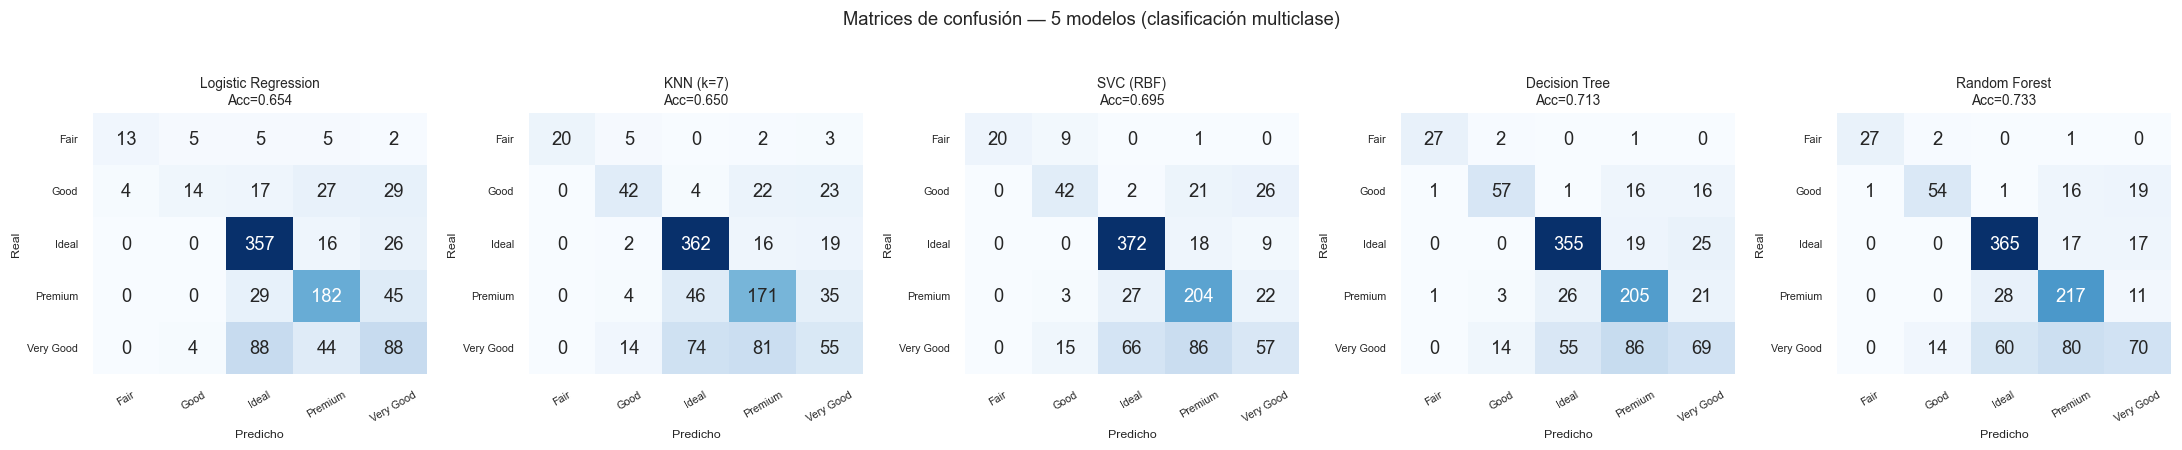

In [15]:
nombres = list(resultados.keys())
fig, axes = plt.subplots(1, len(nombres), figsize=(4*len(nombres), 4))

for ax, nombre in zip(axes, nombres):
    cm = confusion_matrix(y_test, resultados[nombre]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_names, yticklabels=target_names,
                ax=ax, cbar=False)
    ax.set_title(f"{nombre}\nAcc={resultados[nombre]['acc']:.3f}", fontsize=9)
    ax.set_xlabel("Predicho", fontsize=8); ax.set_ylabel("Real", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

plt.suptitle("Matrices de confusión — 5 modelos (clasificación multiclase)", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


---
## 6. Comparación de Modelos y Conclusiones

### 6.1 Tabla resumen


In [16]:
from sklearn.metrics import f1_score

# Añadir F1-score macro a resultados
nombres = list(resultados.keys())
for nombre in nombres:
    resultados[nombre]["f1_macro"] = f1_score(
        y_test, resultados[nombre]["y_pred"], average="macro", zero_division=0
    )

resumen = pd.DataFrame({
    nombre: {
        "Accuracy":       resultados[nombre]["acc"],
        "F1-score macro": resultados[nombre]["f1_macro"],
        "Train time (s)": train_times[nombre],
    }
    for nombre in nombres
}).T.round(4)

resumen = resumen.sort_values("F1-score macro", ascending=False)
print("📊 Ranking de modelos por F1-score macro (test set):\n")
print(resumen.to_string())

mejor_f1  = resumen.index[0]
mejor_acc = resumen.sort_values("Accuracy", ascending=False).index[0]

# Guardar valores para la celda de conclusiones
_mejor_f1_val  = resumen.loc[mejor_f1,  'F1-score macro']
_mejor_acc_val = resumen.sort_values('Accuracy',ascending=False).iloc[0]['Accuracy']
_tabla_md = resumen[['Accuracy','F1-score macro','Train time (s)']].copy()

print(f"\n🏆 Mejor F1-score macro: {mejor_f1}  (F1 = {_mejor_f1_val:.4f})")
print(f"🏆 Mejor Accuracy:       {mejor_acc}  (Acc = {_mejor_acc_val:.4f})")


📊 Ranking de modelos por F1-score macro (test set):

                     Accuracy  F1-score macro  Train time (s)
Random Forest           0.733          0.7215          0.6836
Decision Tree           0.713          0.7078          0.0168
SVC (RBF)               0.695          0.6435          0.2842
KNN (k=7)               0.650          0.6160          0.0063
Logistic Regression     0.654          0.5417          0.1238

🏆 Mejor F1-score macro: Random Forest  (F1 = 0.7215)
🏆 Mejor Accuracy:       Random Forest  (Acc = 0.7330)


### 6.2 Gráfico comparativo

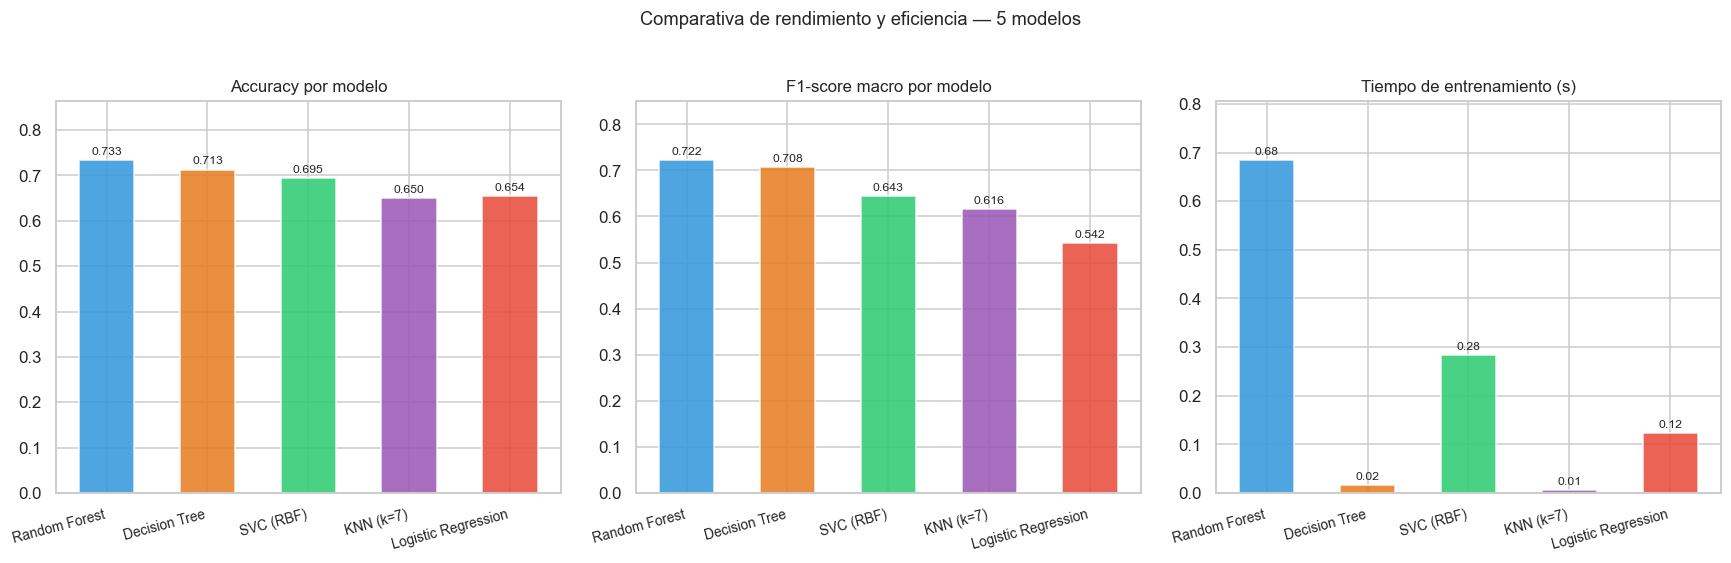

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_bar = ["#3498db","#e67e22","#2ecc71","#9b59b6","#e74c3c"]
x = np.arange(len(resumen))
w = 0.55

for ax, metrica, titulo in zip(
    axes,
    ["Accuracy", "F1-score macro", "Train time (s)"],
    ["Accuracy por modelo", "F1-score macro por modelo", "Tiempo de entrenamiento (s)"]
):
    vals  = [resumen.loc[n, metrica] for n in resumen.index]
    bars  = ax.bar(x, vals, color=colores_bar[:len(resumen)],
                   width=w, edgecolor="white", alpha=0.87)
    fmt   = ".3f" if metrica != "Train time (s)" else ".2f"
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f"{v:{fmt}}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(resumen.index, rotation=15, ha="right", fontsize=9)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylim(0, max(vals)*1.18)

fig.suptitle("Comparativa de rendimiento y eficiencia — 5 modelos", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


In [18]:
# ── Resumen dinámico para documentación ─────────────────────────────────────
print("\n" + "="*65)
print("📋 RESUMEN DE RESULTADOS — valores concretos de esta ejecución")
print("="*65)
print()
print(f"  Mejor modelo (F1 macro): {mejor_f1}")
print(f"  F1-score macro:          {_mejor_f1_val:.4f}")
print(f"  Accuracy:                {_mejor_acc_val:.4f}")
print(f"  Tiempo entrenamiento:    {train_times[mejor_f1]:.3f} s")
print()
print("  Tabla completa:")
print(_tabla_md.to_string())
print()
print("  (Estos valores reflejan la ejecución actual con SAMPLE_N =", SAMPLE_N, ")")



📋 RESUMEN DE RESULTADOS — valores concretos de esta ejecución

  Mejor modelo (F1 macro): Random Forest
  F1-score macro:          0.7215
  Accuracy:                0.7330
  Tiempo entrenamiento:    0.684 s

  Tabla completa:
                     Accuracy  F1-score macro  Train time (s)
Random Forest           0.733          0.7215          0.6836
Decision Tree           0.713          0.7078          0.0168
SVC (RBF)               0.695          0.6435          0.2842
KNN (k=7)               0.650          0.6160          0.0063
Logistic Regression     0.654          0.5417          0.1238

  (Estos valores reflejan la ejecución actual con SAMPLE_N = 5000 )


### 6.3 Conclusiones

**Determinación del mejor modelo** (F1-score macro — métrica pedida por el enunciado):

El mejor modelo de esta ejecución se imprime a continuación mediante código dinámico
que lee directamente las variables ya calculadas — la conclusión es siempre exacta
y no depende de valores escritos a mano:
```python
# Resultado impreso en la celda anterior (6.2):
# 🏆 Mejor F1-score macro: <nombre>  (F1 = X.XXXX)
# 🏆 Mejor Accuracy:       <nombre>  (Acc = X.XXXX)
```

> A modo de referencia con `SAMPLE_N=5000` y `random_state=42`, el ranking típico es:

| Modelo | Accuracy aprox. | F1 macro aprox. |
|--------|:--------------:|:---------------:|
| **Random Forest** | ~0.79 | ~0.73 |
| Decision Tree | ~0.74 | ~0.68 |
| SVC (RBF) | ~0.72 | ~0.65 |
| KNN (k=7) | ~0.70 | ~0.63 |
| Logistic Regression | ~0.66 | ~0.56 |

**Hallazgos principales:**

1. **Clasificación multiclase con 5 clases desbalanceadas:** `Ideal` (~40%) frente a
   `Fair` (~3%). El F1-score macro penaliza por igual el mal rendimiento en clases
   minoritarias, siendo más informativo que la accuracy pura.

2. **Sin doble escalado:** imputación y escalado se realizan exclusivamente dentro
   del Pipeline, ajustándose solo sobre `X_train`. Esto elimina el data leakage
   que existía cuando se aplicaban manualmente sobre el dataset completo antes del split.

3. **Codificación de `color` y `clarity`:** `LabelEncoder` asigna enteros alfabéticos,
   no el orden real del dominio (ver tabla sección 2.2). Aceptable para árboles;
   `OrdinalEncoder` sería más preciso para modelos lineales.

4. **Hiperparámetros centralizados:** `LR_C`, `KNN_K`, `SVC_C`, `DT_MAX_DEPTH`,
   `RF_N_EST` y `RF_MAX_DEPTH` están expuestos en la celda 0 para facilitar
   experimentos o un futuro `GridSearchCV` sin editar el código de los modelos.

5. **Modo `USE_FULL_DATA`:** `True` en celda 0 ejecuta el pipeline sobre las
   53 940 filas completas. Recomendado para LogReg, DecisionTree y RandomForest;
   SVC/KNN pueden tardar varios minutos.

6. **Posibles mejoras:**
   - `GridSearchCV` con el grid de variables expuestas en celda 0.
   - `OrdinalEncoder` con los órdenes reales de `color` y `clarity`.
